# Report 1 — Selective Attention Game: Validation Study
## Data Cleaning · EDA · Descriptive Statistics · Normality Testing · Non-Parametric Hypothesis Tests

**Design:** 2 × 2 Mixed Factorial  
**N = 37** · Single Target (n = 21) · Multiple Target (n = 16)  
**Factor 1 (between-subjects):** Target Load — Single vs Multiple  
**Factor 2 (within-subjects):** Modality — Lab Task vs Selective Attention Game  
**DVs:** Reaction Time (ms) · Accuracy (0–1 ratio)

---
> **Scope of this report:** Data loading, cleaning, EDA, descriptive statistics,  
> normality testing, and non-parametric hypothesis tests only.  
> ANOVA, regression, and GLMs are excluded from this phase.


---
## Section 1 · Introduction

### Selective Attention and the Role of Target Load

Selective attention is the cognitive capacity to concentrate on task-relevant stimuli  
while filtering out competing distractors. Its efficiency is highly sensitive to  
**target load** — the number of targets a participant must identify within a display.  
In a single-target condition, attention can be deployed focally; in a multiple-target  
condition, parallel tracking demands are imposed, increasing cognitive load and typically  
slowing response times (Treisman & Gelade, 1980; Wolfe, 1994).

### The Case for Gamified Cognitive Assessment

Standard laboratory paradigms (PsychoPy visual-search tasks, etc.) offer high experimental  
control but suffer from low ecological validity, participant burden, and limited scalability  
outside a clinic or research setting. **Gamification** — embedding cognitive demands within  
game-like environments — has emerged as a promising approach to improving engagement,  
enabling remote administration, and reaching larger or more diverse samples  
(Lumsden et al., 2016).

The **Selective Attention Game** developed here mirrors the structure of the lab visual-search  
task: participants must identify one or more targets among distractors under time pressure,  
with difficulty scaling across game levels. If the game produces performance indices that  
correlate with, and are sensitive to the same manipulations as, the gold-standard lab task,  
it can be considered a **valid operational substitute**.

### Why Validate?

Validation — specifically *concurrent validity* — establishes whether the new measure  
ranks participants in the same order as the accepted measure. Without this evidence, any  
group differences observed in the game could reflect interface artefacts (touchscreen  
latency, unfamiliar controls) rather than genuine attentional capacity. This report  
therefore tests three focused research questions:

| # | Research Question | Design element tested |
|---|---|---|
| **RQ1** | Is there a positive correlation between Game and Lab performance? | Concurrent validity |
| **RQ2** | Is performance worse in Multiple vs Single target conditions? | Sensitivity to load |
| **RQ3** | Does the Game interface alter performance vs the Lab? | Modality equivalence |


---
## Section 2 · Data Loading & Preprocessing

### Dataset overview

| File | Task | Condition | Trials/rows |
|---|---|---|---|
| `single_lab_combined.csv` | Lab (PsychoPy) | Single Target | 15 trials × 8 participants = 120 rows |
| `multiple_lab_combined.csv` | Lab (PsychoPy) | Multiple Target | 15 trials × 16 participants = 240 rows |
| `single_phone_combined.csv` | Game | Single Target | variable levels, 21 participants |
| `multiple_phone_combined.csv` | Game | Multiple Target | variable levels, 16 participants |

### RT extraction rationale

- **Lab files:** RT is stored as a stringified Python list in `mouse.time` (seconds).  
  We extract the **first element** (initial click) and convert to milliseconds.  
- **Game files:** RT is directly available as `InitialResponseTime(ms)`.  
  Only **completed** levels (`Completed == True`) are included.

### Accuracy extraction

- **Lab:** 1 if `mouse.clicked_name` contains `'target'`, 0 otherwise.  
- **Game:** `SuccessRate(%) / 100`, available directly.

### Three dataframes

| Name | Content | Purpose |
|---|---|---|
| `df_raw` | All trial-level observations, no filtering | Audit, before/after plots |
| `df_clean` | Trial-level, IQR outliers removed | EDA visualisations |
| `df_part` | Participant-level means (one row per person per condition) | Hypothesis tests |

IQR outlier rule applied to **participant-level mean RT**:  
values below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR are flagged and removed.


In [1]:
import ast, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, mannwhitneyu, wilcoxon, spearmanr

warnings.filterwarnings('ignore')

# ── Global style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.facecolor': 'white',
})
sns.set_theme(style='whitegrid', font_scale=0.95)

PAL = {
    'SL': '#3A7EC6',   # Single Lab
    'SG': '#85C1E9',   # Single Game
    'ML': '#E06B3A',   # Multi Lab
    'MG': '#F0B27A',   # Multi Game
}
COND_ORDER = ['Single\nLab', 'Single\nGame', 'Multi\nLab', 'Multi\nGame']
COND_PAL   = {c: list(PAL.values())[i] for i, c in enumerate(COND_ORDER)}


In [2]:
# ════════════════════════════════════════════════════════════════════════════
# 2.1  Helper functions
# ════════════════════════════════════════════════════════════════════════════

def parse_rt(x):
    """Extract first click time from PsychoPy stringified list; convert s → ms."""
    try:
        return float(ast.literal_eval(str(x))[0]) * 1000
    except Exception:
        return np.nan


def iqr_flag(series):
    """Return boolean mask: True where value is an IQR outlier."""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr    = q3 - q1
    return (series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)


# ════════════════════════════════════════════════════════════════════════════
# 2.2  Load raw data
# ════════════════════════════════════════════════════════════════════════════

# ── Lab: Single Target ───────────────────────────────────────────────────────
sl_raw = pd.read_csv('single_lab_combined.csv', encoding='utf-8-sig', on_bad_lines='skip')
sl_raw = sl_raw[sl_raw['target_col'].notna()].copy()
sl_raw['RT_ms']    = sl_raw['mouse.time'].apply(parse_rt)
sl_raw['Accuracy'] = sl_raw['mouse.clicked_name'].apply(
    lambda x: 1.0 if 'target' in str(x).lower() else 0.0)
sl_raw['Condition'] = 'Single\nLab'
sl_raw['Load']      = 'Single'
sl_raw['Modality']  = 'Lab'
sl_raw = sl_raw.rename(columns={'FileNumber': 'ParticipantID'})
sl_raw = sl_raw[['ParticipantID', 'Condition', 'Load', 'Modality', 'RT_ms', 'Accuracy']]

# ── Lab: Multiple Target ─────────────────────────────────────────────────────
ml_raw = pd.read_csv('multiple_lab_combined.csv', encoding='utf-8-sig', on_bad_lines='skip')
ml_raw = ml_raw[ml_raw['target_col'].notna()].copy()
ml_raw['RT_ms']    = ml_raw['mouse.time'].apply(parse_rt)
ml_raw['Accuracy'] = ml_raw['mouse.clicked_name'].apply(
    lambda x: 1.0 if 'target' in str(x).lower() else 0.0)
ml_raw['Condition'] = 'Multi\nLab'
ml_raw['Load']      = 'Multiple'
ml_raw['Modality']  = 'Lab'
ml_raw = ml_raw.rename(columns={'FileNumber': 'ParticipantID'})
ml_raw = ml_raw[['ParticipantID', 'Condition', 'Load', 'Modality', 'RT_ms', 'Accuracy']]

# ── Game: Single Target ──────────────────────────────────────────────────────
sg_raw = pd.read_csv('single_phone_combined.csv', encoding='utf-8-sig')
sg_raw = sg_raw[sg_raw['Completed'] == True].copy()
sg_raw['RT_ms']     = sg_raw['InitialResponseTime(ms)'].astype(float)
sg_raw['Accuracy']  = sg_raw['SuccessRate(%)'] / 100
sg_raw['Condition'] = 'Single\nGame'
sg_raw['Load']      = 'Single'
sg_raw['Modality']  = 'Game'
sg_raw = sg_raw.rename(columns={'FileNumber': 'ParticipantID'})
sg_raw = sg_raw[['ParticipantID', 'Condition', 'Load', 'Modality', 'RT_ms', 'Accuracy']]

# ── Game: Multiple Target ────────────────────────────────────────────────────
mg_raw = pd.read_csv('multiple_phone_combined.csv', encoding='utf-8-sig')
mg_raw = mg_raw[mg_raw['Completed'] == True].copy()
mg_raw['RT_ms']     = mg_raw['InitialResponseTime(ms)'].astype(float)
mg_raw['Accuracy']  = mg_raw['SuccessRate(%)'] / 100
mg_raw['Condition'] = 'Multi\nGame'
mg_raw['Load']      = 'Multiple'
mg_raw['Modality']  = 'Game'
mg_raw = mg_raw.rename(columns={'FileNumber': 'ParticipantID'})
mg_raw = mg_raw[['ParticipantID', 'Condition', 'Load', 'Modality', 'RT_ms', 'Accuracy']]

# ── Stack into one raw trial-level dataframe ─────────────────────────────────
df_raw = pd.concat([sl_raw, ml_raw, sg_raw, mg_raw], ignore_index=True)
df_raw = df_raw[df_raw['RT_ms'].notna() & (df_raw['RT_ms'] > 0)].reset_index(drop=True)

print(f"df_raw shape: {df_raw.shape}")
print(df_raw.groupby('Condition')[['RT_ms','Accuracy']].agg(['count','mean']).round(3))


df_raw shape: (863, 6)
             RT_ms           Accuracy       
             count      mean    count   mean
Condition                                   
Multi\nGame    171  1741.450      171  0.969
Multi\nLab     240  1605.039      240  1.000
Single\nGame   332  3141.187      332  0.980
Single\nLab    120  1698.230      120  1.000


In [3]:
# ════════════════════════════════════════════════════════════════════════════
# 2.3  Outlier detection & cleaned dataframe
# ════════════════════════════════════════════════════════════════════════════

# Step 1: compute participant-level mean RT per condition
part_means = (df_raw.groupby(['ParticipantID', 'Condition'])['RT_ms']
              .mean().reset_index().rename(columns={'RT_ms': 'mean_RT'}))

# Step 2: flag outliers within each condition using IQR
part_means['outlier'] = (
    part_means.groupby('Condition')['mean_RT']
    .transform(iqr_flag)
)

outlier_ids = part_means.loc[part_means['outlier'],
              ['ParticipantID','Condition','mean_RT']]
print("IQR outlier participants detected:")
print(outlier_ids.to_string(index=False) if len(outlier_ids) else "  None detected")

# Step 3: remove flagged participants from trial-level data
flagged = part_means[part_means['outlier']].set_index(['ParticipantID','Condition']).index
df_raw['_key'] = list(zip(df_raw['ParticipantID'], df_raw['Condition']))
df_clean = df_raw[~df_raw['_key'].isin(flagged)].drop(columns='_key').reset_index(drop=True)
df_raw   = df_raw.drop(columns='_key')

print(f"\ndf_raw   shape: {df_raw.shape}")
print(f"df_clean shape: {df_clean.shape}")
print(f"Observations removed: {len(df_raw) - len(df_clean)}")

# ════════════════════════════════════════════════════════════════════════════
# 2.4  Participant-level means dataframe  (used for all hypothesis tests)
# ════════════════════════════════════════════════════════════════════════════

df_part = (df_clean.groupby(['ParticipantID', 'Condition', 'Load', 'Modality'])
           [['RT_ms', 'Accuracy']].mean().reset_index())

print(f"\ndf_part shape: {df_part.shape}  (one row per participant per condition)")
print(df_part.head(8).to_string(index=False))


IQR outlier participants detected:
 ParticipantID   Condition     mean_RT
             1 Single\nLab 2331.349807

df_raw   shape: (863, 6)
df_clean shape: (848, 6)
Observations removed: 15

df_part shape: (60, 6)  (one row per participant per condition)
 ParticipantID    Condition   Load Modality       RT_ms  Accuracy
             1 Single\nGame Single     Game 3107.333333  1.000000
             2 Single\nGame Single     Game 3977.733333  1.000000
             2  Single\nLab Single      Lab 1865.424367  1.000000
             3 Single\nGame Single     Game 2439.533333  1.000000
             3  Single\nLab Single      Lab 1762.399107  1.000000
             4 Single\nGame Single     Game 3026.733333  1.000000
             4  Single\nLab Single      Lab 1452.931387  1.000000
             5 Single\nGame Single     Game 4682.600000  0.966667


---
## Section 3 · Exploratory Data Analysis & Visualisation


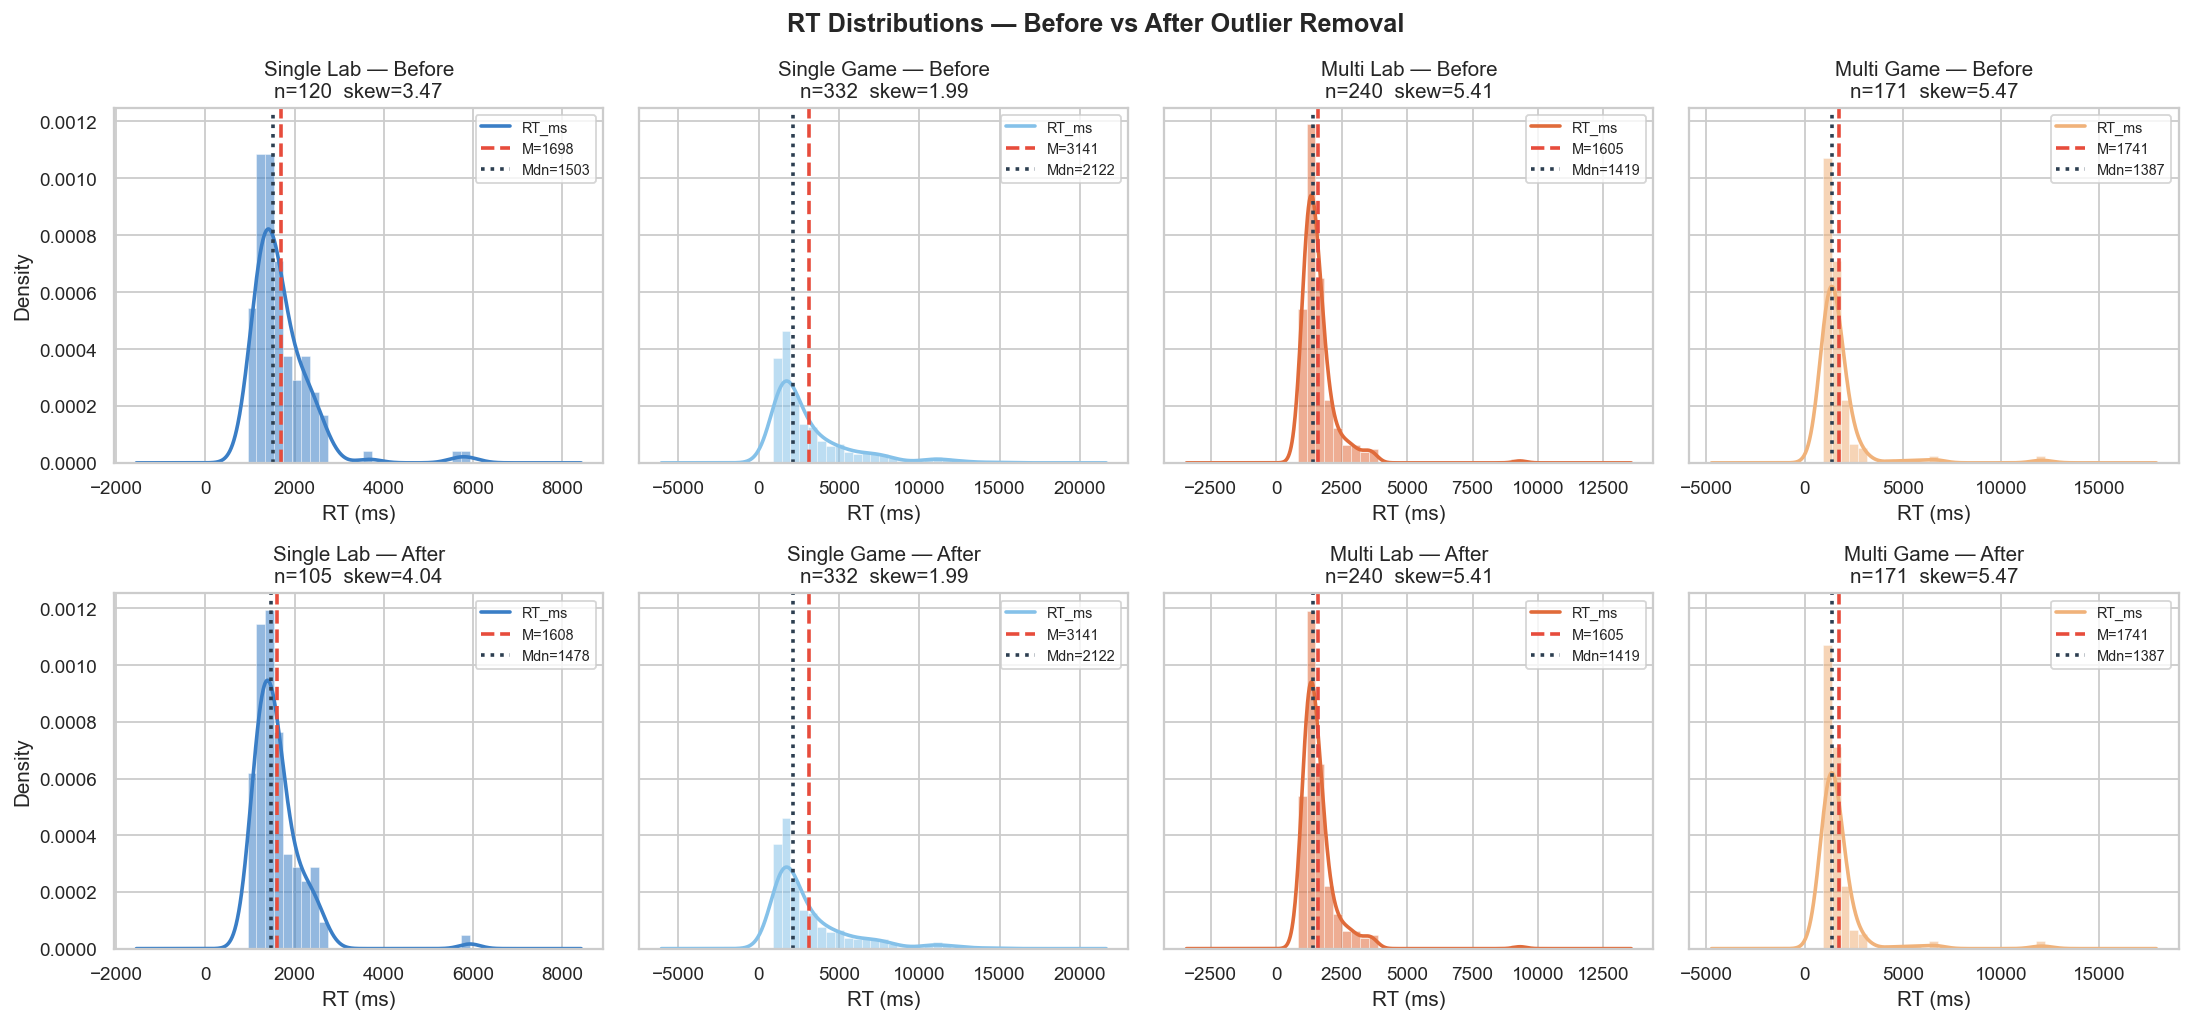

✓ Figure 1 saved


In [4]:
# ════════════════════════════════════════════════════════════════════════════
# 3.1  Before vs After outlier removal — RT distributions
# ════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 4, figsize=(17, 8), sharey='row')
fig.suptitle('RT Distributions — Before vs After Outlier Removal',
             fontsize=14, fontweight='bold')

conditions = ['Single\nLab', 'Single\nGame', 'Multi\nLab', 'Multi\nGame']

for col, cond in enumerate(conditions):
    color = list(PAL.values())[col]
    for row, (df_src, label) in enumerate([(df_raw, 'Before'), (df_clean, 'After')]):
        ax  = axes[row, col]
        dat = df_src[df_src['Condition'] == cond]['RT_ms'].dropna()
        ax.hist(dat, bins=25, color=color, alpha=0.55, density=True,
                edgecolor='white', lw=0.4)
        dat.plot.kde(ax=ax, color=color, lw=2)
        ax.axvline(dat.mean(),   color='#E74C3C', lw=2, ls='--',
                   label=f'M={dat.mean():.0f}')
        ax.axvline(dat.median(), color='#2C3E50', lw=2, ls=':',
                   label=f'Mdn={dat.median():.0f}')
        ax.set_title(f'{cond.replace(chr(10)," ")} — {label}\n'
                     f'n={len(dat)}  skew={dat.skew():.2f}')
        ax.set_xlabel('RT (ms)')
        ax.set_ylabel('Density' if col == 0 else '')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig01_before_after.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figure 1 saved')


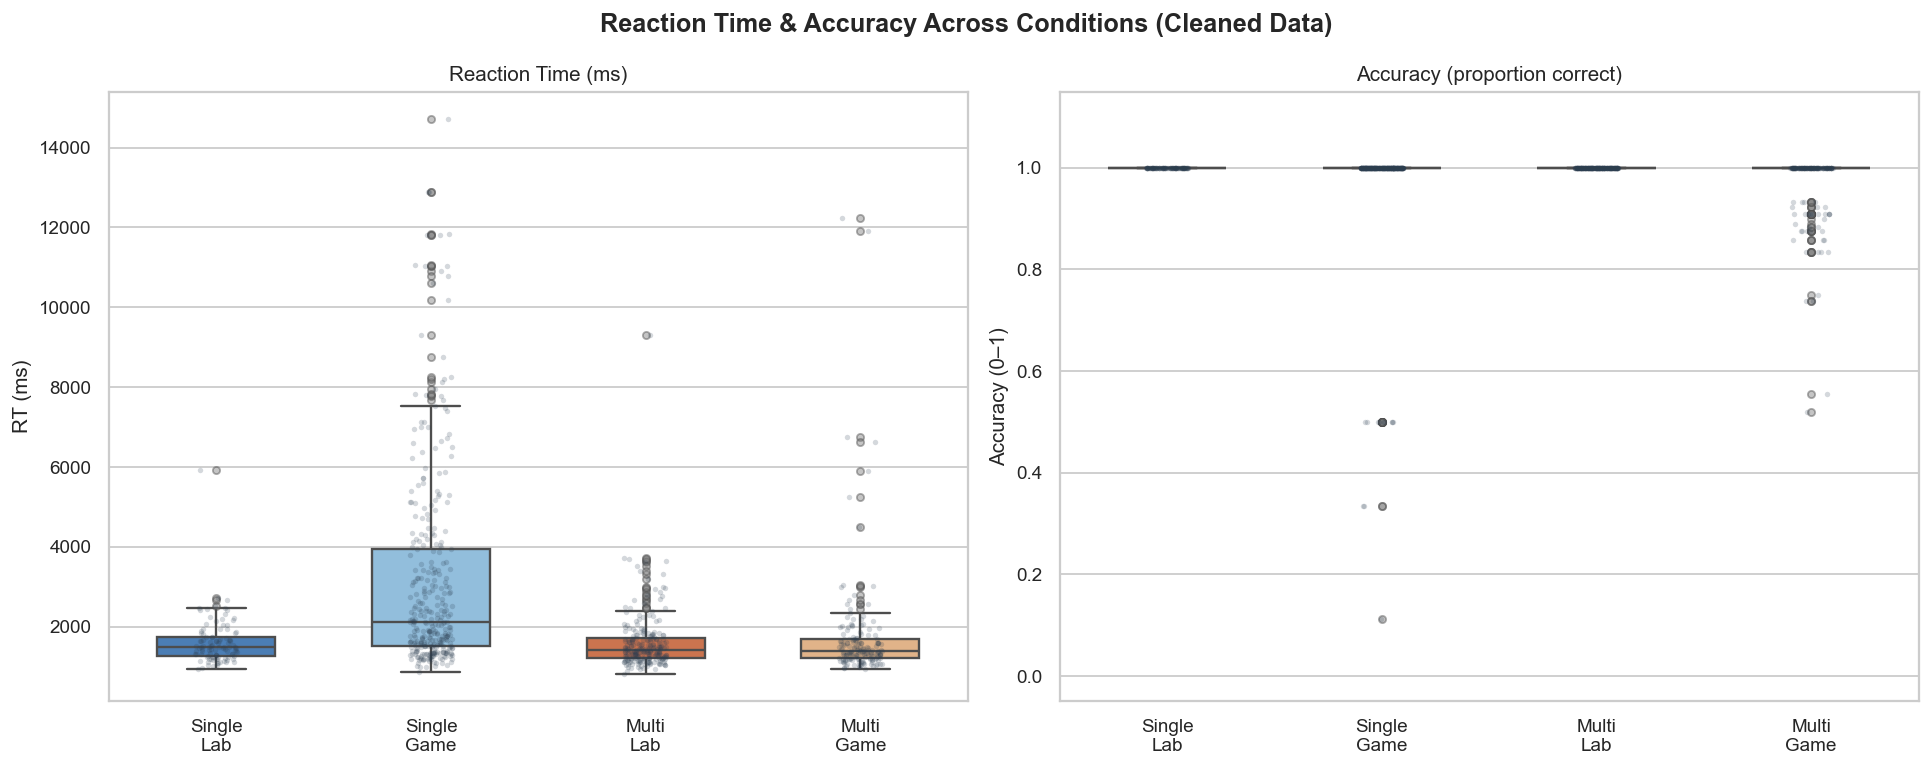

✓ Figure 2 saved


In [5]:
# ════════════════════════════════════════════════════════════════════════════
# 3.2  Boxplots — RT and Accuracy across 4 conditions (cleaned data)
# ════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Reaction Time & Accuracy Across Conditions (Cleaned Data)',
             fontsize=14, fontweight='bold')

# ── RT ────────────────────────────────────────────────────────────────────────
ax = axes[0]
sns.boxplot(data=df_clean, x='Condition', y='RT_ms',
            order=COND_ORDER, palette=COND_PAL,
            width=0.55, linewidth=1.3,
            flierprops=dict(marker='o', ms=4, alpha=0.45, markerfacecolor='grey'),
            ax=ax)
sns.stripplot(data=df_clean, x='Condition', y='RT_ms',
              order=COND_ORDER, color='#2C3E50',
              alpha=0.2, size=3, jitter=True, ax=ax)
ax.set_title('Reaction Time (ms)')
ax.set_xlabel('')
ax.set_ylabel('RT (ms)')

# ── Accuracy ──────────────────────────────────────────────────────────────────
ax2 = axes[1]
sns.boxplot(data=df_clean, x='Condition', y='Accuracy',
            order=COND_ORDER, palette=COND_PAL,
            width=0.55, linewidth=1.3,
            flierprops=dict(marker='o', ms=4, alpha=0.45, markerfacecolor='grey'),
            ax=ax2)
sns.stripplot(data=df_clean, x='Condition', y='Accuracy',
              order=COND_ORDER, color='#2C3E50',
              alpha=0.2, size=3, jitter=True, ax=ax2)
ax2.set_title('Accuracy (proportion correct)')
ax2.set_xlabel('')
ax2.set_ylabel('Accuracy (0–1)')
ax2.set_ylim(-0.05, 1.15)

plt.tight_layout()
plt.savefig('fig02_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figure 2 saved')


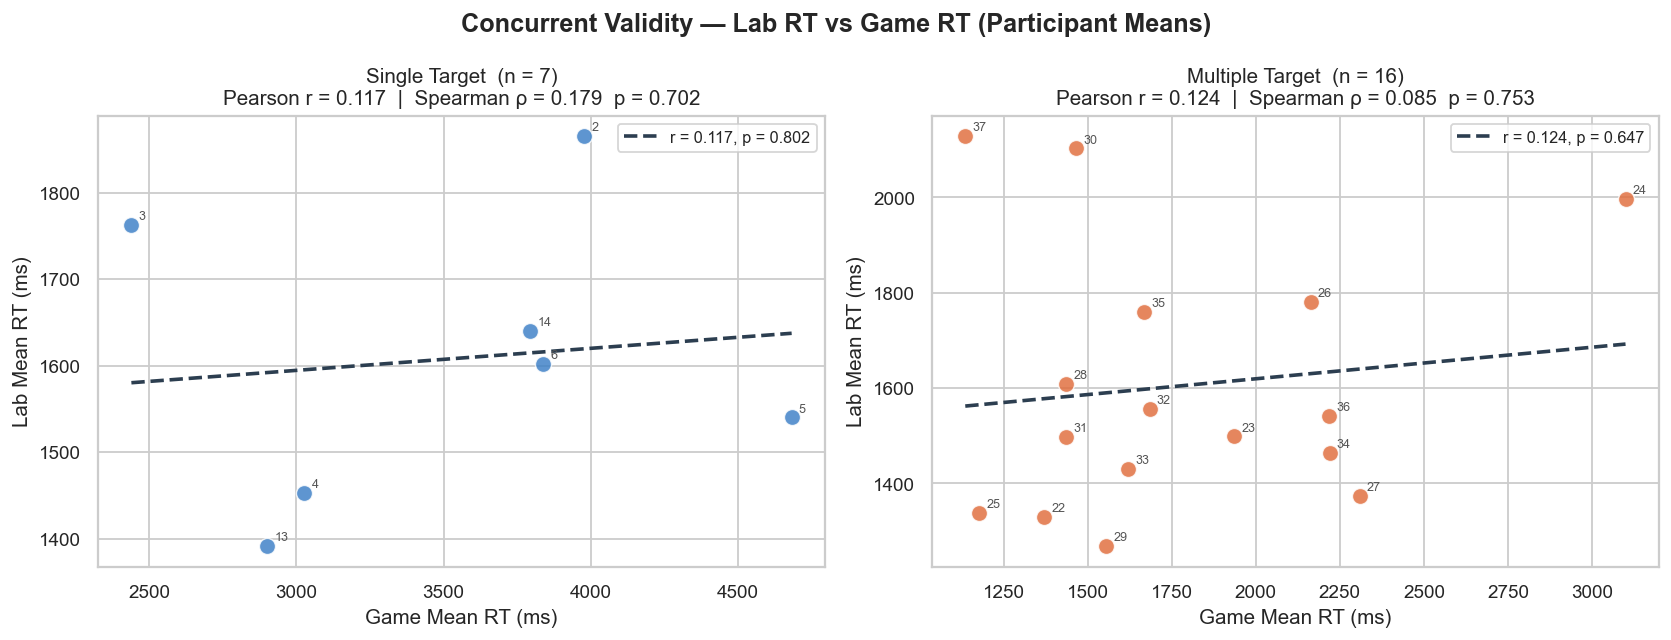

✓ Figure 3 saved


In [6]:
# ════════════════════════════════════════════════════════════════════════════
# 3.3  Scatter plots — Lab RT vs Game RT (concurrent validity, RQ1)
# ════════════════════════════════════════════════════════════════════════════

# Participant means per modality per load condition
lab_means  = (df_part[df_part['Modality'] == 'Lab']
              .set_index(['ParticipantID','Load'])['RT_ms']
              .rename('Lab_RT'))
game_means = (df_part[df_part['Modality'] == 'Game']
              .set_index(['ParticipantID','Load'])['RT_ms']
              .rename('Game_RT'))
paired = pd.concat([lab_means, game_means], axis=1).dropna().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Concurrent Validity — Lab RT vs Game RT (Participant Means)',
             fontsize=14, fontweight='bold')

for ax, load, color in [(axes[0],'Single','#3A7EC6'), (axes[1],'Multiple','#E06B3A')]:
    sub = paired[paired['Load'] == load]
    ax.scatter(sub['Game_RT'], sub['Lab_RT'],
               color=color, s=80, alpha=0.82, edgecolors='white',
               linewidths=0.8, zorder=3)

    # Annotate participant IDs
    for _, row in sub.iterrows():
        ax.annotate(str(int(row['ParticipantID'])),
                    (row['Game_RT'], row['Lab_RT']),
                    fontsize=7, xytext=(4, 3), textcoords='offset points',
                    color='#555555')

    # Regression line
    if len(sub) >= 3:
        m, b, r, p, _ = stats.linregress(sub['Game_RT'], sub['Lab_RT'])
        xs = np.linspace(sub['Game_RT'].min(), sub['Game_RT'].max(), 100)
        ax.plot(xs, m * xs + b, color='#2C3E50', lw=2, ls='--',
                label=f'r = {r:.3f}, p = {p:.3f}')
        rs, ps = spearmanr(sub['Lab_RT'], sub['Game_RT'])
        ax.set_title(f'{load} Target  (n = {len(sub)})\n'
                     f'Pearson r = {r:.3f}  |  Spearman ρ = {rs:.3f}  p = {ps:.3f}')
        ax.legend(fontsize=9)

    ax.set_xlabel('Game Mean RT (ms)')
    ax.set_ylabel('Lab Mean RT (ms)')

plt.tight_layout()
plt.savefig('fig03_scatter_validity.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figure 3 saved')


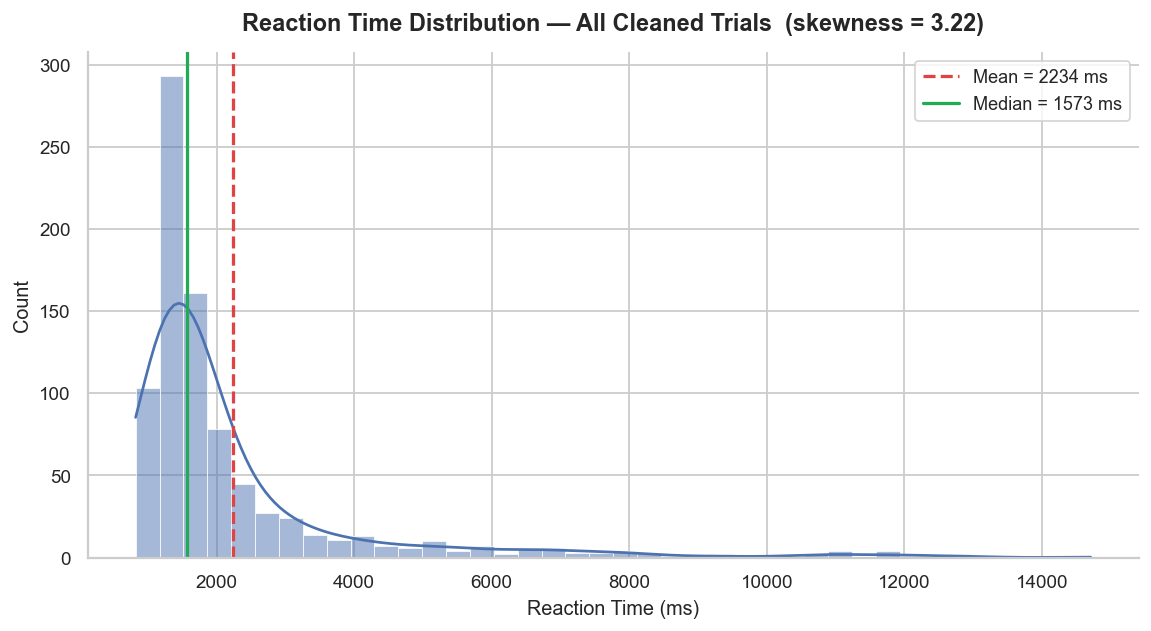


Descriptive summary — RT_ms (all cleaned trials):
  Mean     : 2234.3 ms
  Median   : 1572.9 ms
  Std Dev  : 1888.2 ms
  Skewness : 3.222  (right-skewed → supports non-parametric tests)


In [7]:
# ════════════════════════════════════════════════════════════════════════════
# 3.4  RT Distribution — Histogram with KDE overlay (all cleaned trials)
# ════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    df_clean["RT_ms"],
    bins=40,
    kde=True,
    color="#4C72B0",
    edgecolor="white",
    linewidth=0.4,
    ax=ax
)

# Annotate skewness
skew_val = df_clean["RT_ms"].skew()
ax.axvline(df_clean["RT_ms"].mean(),   color="#DD4444", linewidth=1.8,
           linestyle="--", label=f"Mean = {df_clean['RT_ms'].mean():.0f} ms")
ax.axvline(df_clean["RT_ms"].median(), color="#22AA55", linewidth=1.8,
           linestyle="-",  label=f"Median = {df_clean['RT_ms'].median():.0f} ms")

ax.set_title(
    f"Reaction Time Distribution — All Cleaned Trials  (skewness = {skew_val:.2f})",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("Reaction Time (ms)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig("rt_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nDescriptive summary — RT_ms (all cleaned trials):")
print(f"  Mean     : {df_clean['RT_ms'].mean():.1f} ms")
print(f"  Median   : {df_clean['RT_ms'].median():.1f} ms")
print(f"  Std Dev  : {df_clean['RT_ms'].std():.1f} ms")
print(f"  Skewness : {skew_val:.3f}  {'(right-skewed → supports non-parametric tests)' if skew_val > 0.5 else ''}")

---
## Section 4 · Descriptive Statistics

Mean (M) and Standard Deviation (SD) are computed on **participant-level means**  
(one observation per person per condition) to ensure independence of observations  
and consistency with the hypothesis testing level.


In [8]:
# ════════════════════════════════════════════════════════════════════════════
# 4.1  Descriptive table
# ════════════════════════════════════════════════════════════════════════════

desc_rows = []
for cond in COND_ORDER:
    sub = df_part[df_part['Condition'] == cond]
    for dv, label in [('RT_ms', 'RT (ms)'), ('Accuracy', 'Accuracy')]:
        vals = sub[dv].dropna()
        n    = len(vals)
        se   = vals.std() / np.sqrt(n) if n > 1 else np.nan
        desc_rows.append({
            'Condition':  cond.replace('\n', ' '),
            'DV':         label,
            'N':          n,
            'M':          round(vals.mean(), 2),
            'SD':         round(vals.std(), 2),
            'SE':         round(se, 2),
            'Median':     round(vals.median(), 2),
            'Min':        round(vals.min(), 2),
            'Max':        round(vals.max(), 2),
        })

desc_df = pd.DataFrame(desc_rows)
print(desc_df.to_string(index=False))


  Condition       DV  N       M     SD     SE  Median     Min     Max
 Single Lab  RT (ms)  7 1607.78 166.73  63.02 1602.09 1391.26 1865.42
 Single Lab Accuracy  7    1.00   0.00   0.00    1.00    1.00    1.00
Single Game  RT (ms) 21 3103.62 625.34 136.46 2922.67 2257.93 4682.60
Single Game Accuracy 21    0.98   0.03   0.01    1.00    0.91    1.00
  Multi Lab  RT (ms) 16 1605.04 273.65  68.41 1520.59 1268.69 2128.54
  Multi Lab Accuracy 16    1.00   0.00   0.00    1.00    1.00    1.00
 Multi Game  RT (ms) 16 1780.76 513.56 128.39 1644.24 1135.92 3099.11
 Multi Game Accuracy 16    0.97   0.03   0.01    0.98    0.91    1.00


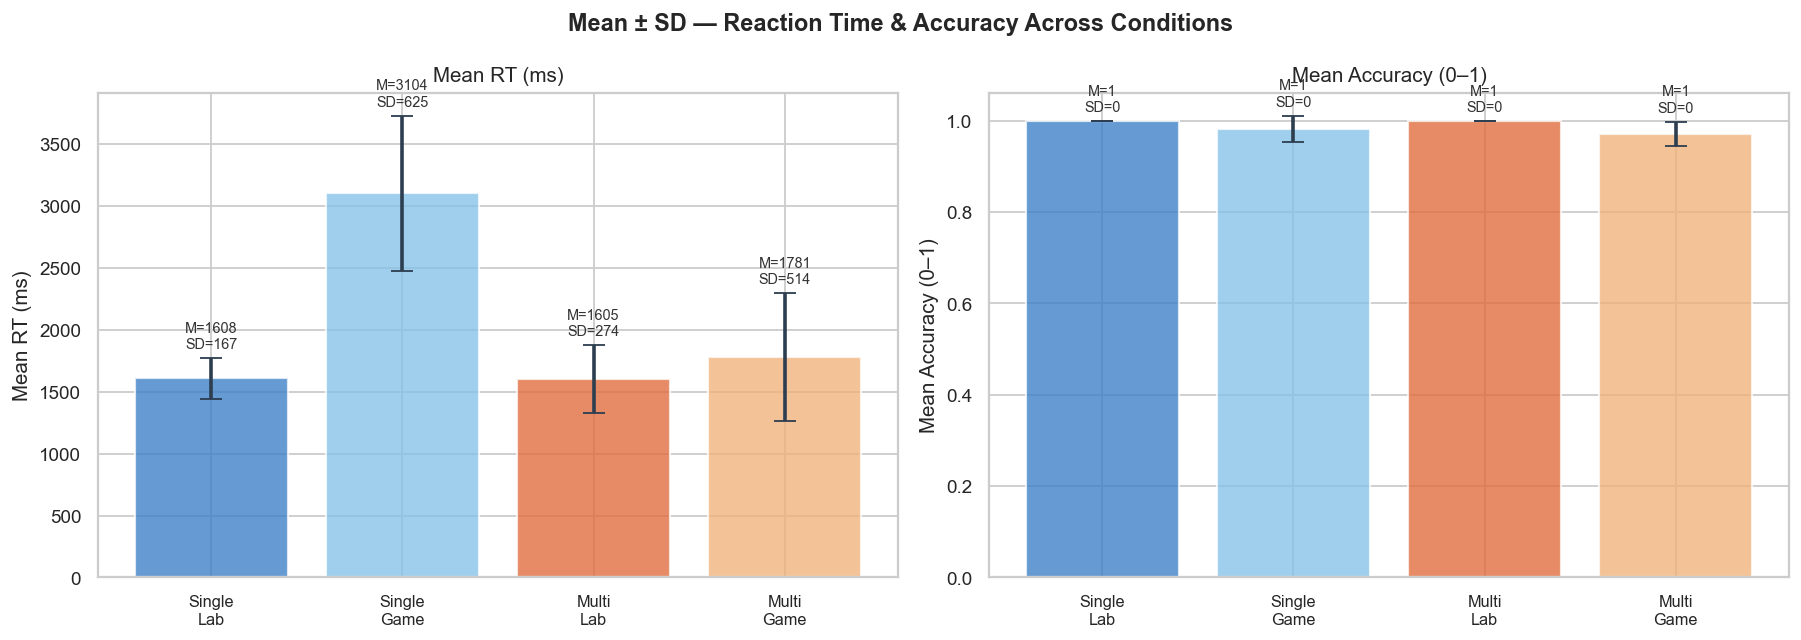

✓ Figure 4 saved


In [9]:
# ════════════════════════════════════════════════════════════════════════════
# 4.2  Visual summary — Mean ± SD bar chart
# ════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Mean ± SD — Reaction Time & Accuracy Across Conditions',
             fontsize=13, fontweight='bold')

for ax, dv, ylabel in [
        (axes[0], 'RT_ms',    'Mean RT (ms)'),
        (axes[1], 'Accuracy', 'Mean Accuracy (0–1)')]:

    cond_stats = (df_part.groupby('Condition')[dv]
                  .agg(['mean','std','count']).reindex(COND_ORDER))
    cond_stats['se'] = cond_stats['std'] / np.sqrt(cond_stats['count'])

    bars = ax.bar(range(4), cond_stats['mean'],
                  color=[COND_PAL[c] for c in COND_ORDER],
                  alpha=0.78, edgecolor='white', linewidth=1.2)
    ax.errorbar(range(4), cond_stats['mean'],
                yerr=cond_stats['std'], fmt='none',  # Using 'std' here
                color='#2C3E50', capsize=6, lw=2)
    ax.set_xticks(range(4))
    ax.set_xticklabels([c.replace('\n', '\n') for c in COND_ORDER], fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)

    for i, (idx, row) in enumerate(cond_stats.iterrows()):
        ax.text(i, row['mean'] + row['std'] + (ax.get_ylim()[1] * 0.02),
                f"M={row['mean']:.0f}\nSD={row['std']:.0f}",  # Using 'std' here
                ha='center', fontsize=8, color='#333333')

plt.tight_layout()
plt.savefig('fig04_means_sd.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figure 4 saved')

---
## Section 5 · Normality Testing — Shapiro-Wilk

The Shapiro-Wilk test (Shapiro & Wilk, 1965) is the most powerful test of normality  
for small samples (n < 50). The null hypothesis is that the data are drawn from a  
normally distributed population.

- **H₀:** The data follow a normal distribution.  
- **H₁:** The data do not follow a normal distribution.  
- **Decision rule:** If p < .05, we reject H₀ and treat the distribution as non-normal.

### Why this matters

Parametric tests (independent samples t-test, paired t-test, Pearson r) assume  
normality. If this assumption is violated, their Type I error rates become inflated  
and effect sizes are biased. When at least one cell fails the normality test,  
non-parametric equivalents must be used.


In [10]:
# ════════════════════════════════════════════════════════════════════════════
# 5.1  Shapiro-Wilk on participant-level means
# ════════════════════════════════════════════════════════════════════════════

sw_rows = []
for cond in COND_ORDER:
    sub = df_part[df_part['Condition'] == cond]
    for dv, dv_label in [('RT_ms','RT (ms)'), ('Accuracy','Accuracy')]:
        vals = sub[dv].dropna()
        n    = len(vals)
        if n < 3:
            sw_rows.append({'Condition':cond.replace('\n',' '),
                            'DV':dv_label,'N':n,'W':np.nan,'p':np.nan,'Verdict':'< 3 obs'})
            continue
        # suppress warning for zero-range data (perfect accuracy in lab)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            w, p = shapiro(vals)
        verdict = '✗ NON-NORMAL' if p < 0.05 else '✓ Normal'
        sw_rows.append({'Condition': cond.replace('\n',' '),
                        'DV': dv_label, 'N': n,
                        'W': round(w, 4), 'p': round(p, 4), 'Verdict': verdict})

sw_df = pd.DataFrame(sw_rows)
print(sw_df.to_string(index=False))

print()
print("─" * 60)
any_nonnormal = (sw_df['p'] < 0.05).any()
print(f"Any condition violates normality (p < .05): {any_nonnormal}")
print()
print("DECISION:")
if any_nonnormal:
    print("  At least one condition fails the Shapiro-Wilk test (p < .05).")
    print("  Parametric tests cannot be applied across the board.")
    print("  → Non-parametric tests will be used for all hypothesis tests")
    print("    to maintain consistency and avoid mixed-method inflation.")
else:
    print("  All conditions pass normality — but sample sizes are small,")
    print("  reducing the test's power. Non-parametric tests are applied")
    print("  as a conservative, robust choice.")


  Condition       DV  N      W      p      Verdict
 Single Lab  RT (ms)  7 0.9753 0.9340     ✓ Normal
 Single Lab Accuracy  7 1.0000 1.0000     ✓ Normal
Single Game  RT (ms) 21 0.9054 0.0447 ✗ NON-NORMAL
Single Game Accuracy 21 0.6650 0.0000 ✗ NON-NORMAL
  Multi Lab  RT (ms) 16 0.8910 0.0579     ✓ Normal
  Multi Lab Accuracy 16 1.0000 1.0000     ✓ Normal
 Multi Game  RT (ms) 16 0.9048 0.0961     ✓ Normal
 Multi Game Accuracy 16 0.9038 0.0925     ✓ Normal

────────────────────────────────────────────────────────────
Any condition violates normality (p < .05): True

DECISION:
  At least one condition fails the Shapiro-Wilk test (p < .05).
  Parametric tests cannot be applied across the board.
  → Non-parametric tests will be used for all hypothesis tests
    to maintain consistency and avoid mixed-method inflation.


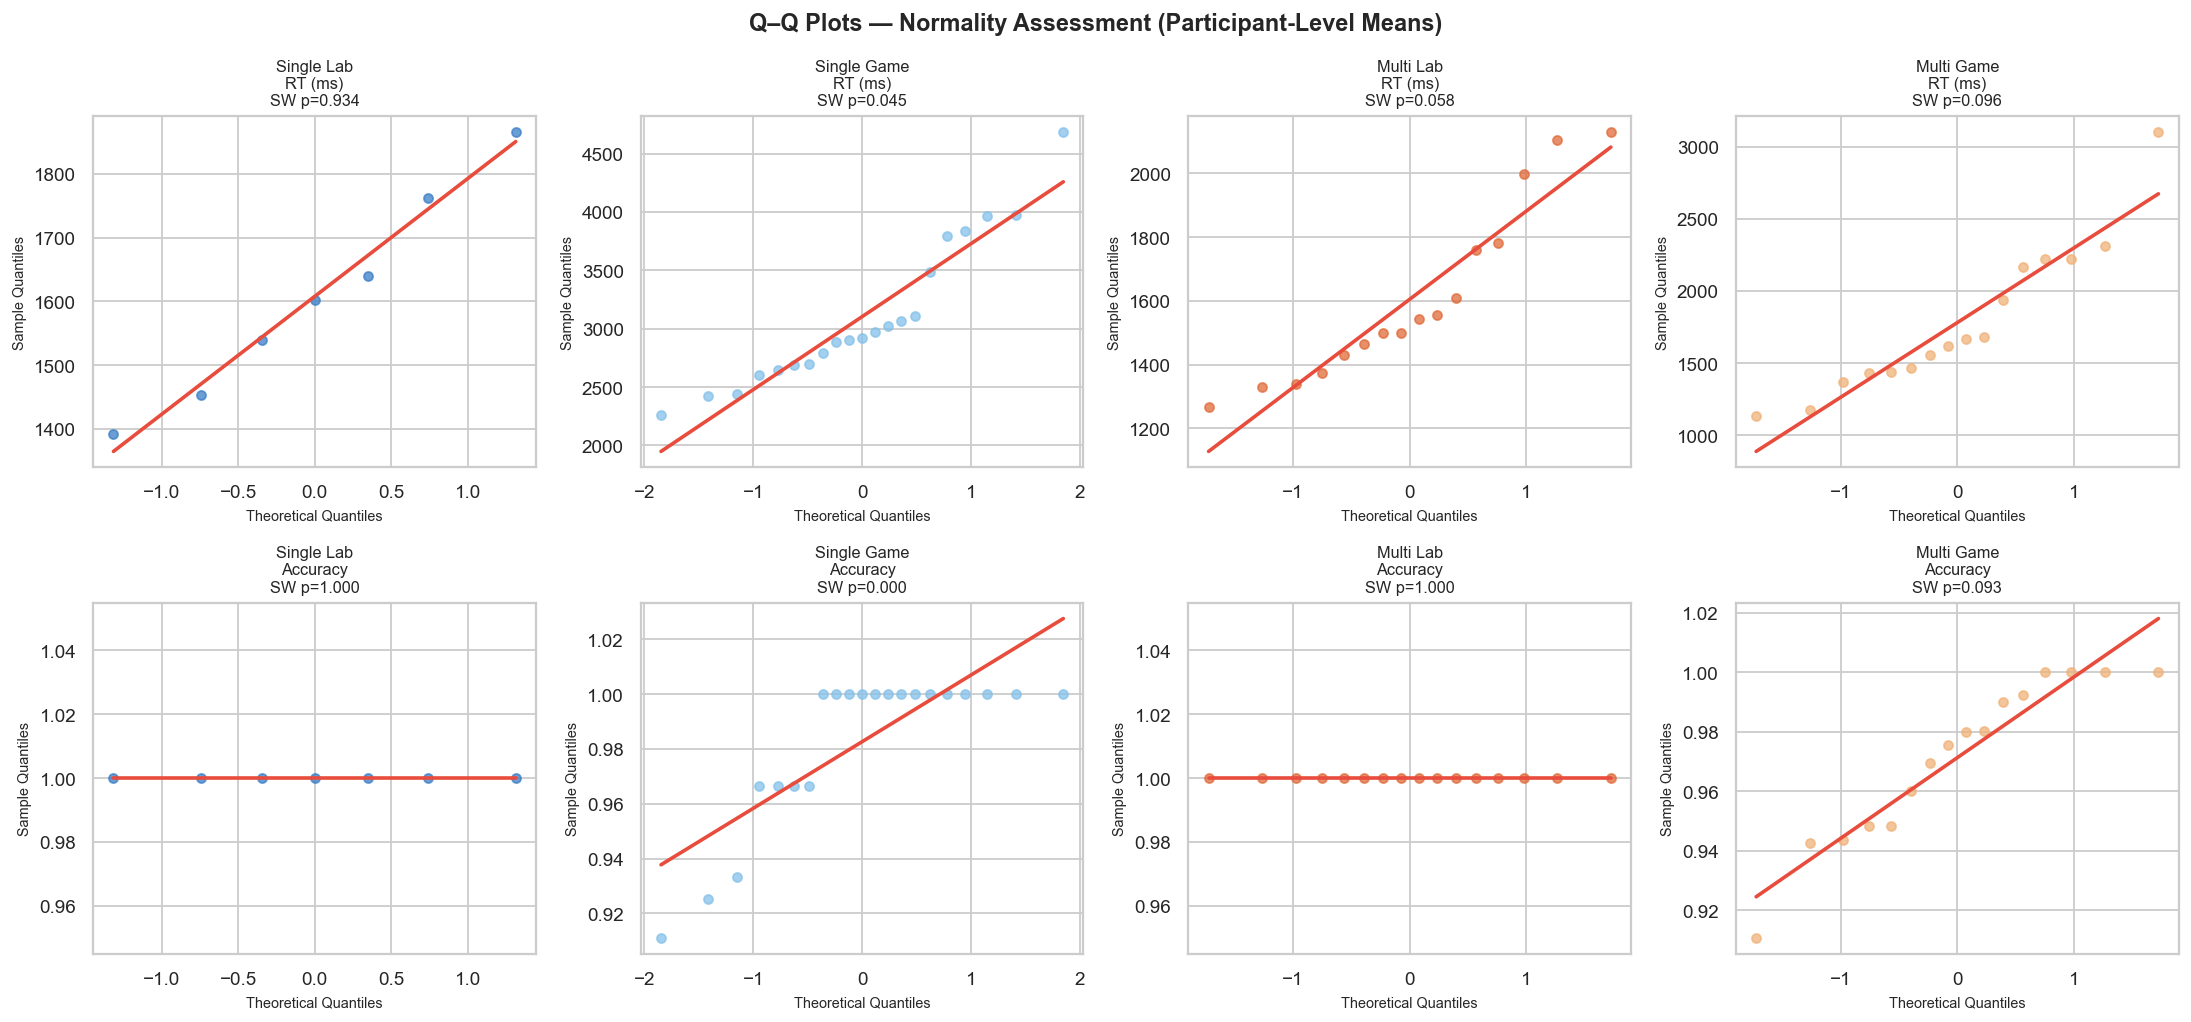

✓ Figure 5 saved


In [11]:
# ════════════════════════════════════════════════════════════════════════════
# 5.2  Q–Q plots for visual normality assessment
# ════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 4, figsize=(17, 8))
fig.suptitle('Q–Q Plots — Normality Assessment (Participant-Level Means)',
             fontsize=13, fontweight='bold')

dvs = [('RT_ms','RT (ms)'), ('Accuracy','Accuracy')]

for row, (dv, dv_label) in enumerate(dvs):
    for col, cond in enumerate(COND_ORDER):
        ax   = axes[row, col]
        vals = df_part[df_part['Condition'] == cond][dv].dropna().values
        color = list(PAL.values())[col]

        if len(vals) < 3:
            ax.text(0.5, 0.5, 'n < 3', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12)
        else:
            (osm, osr), (slope, intercept, r) = stats.probplot(vals, dist='norm')
            ax.plot(osm, osr, 'o', color=color, alpha=0.75, ms=5, zorder=2)
            ax.plot(osm, slope * np.array(osm) + intercept,
                    color='#E74C3C', lw=2, zorder=3)
            w, p = shapiro(vals)
            ax.set_title(f'{cond.replace(chr(10)," ")}\n{dv_label}\nSW p={p:.3f}',
                         fontsize=9)
        ax.set_xlabel('Theoretical Quantiles', fontsize=8)
        ax.set_ylabel('Sample Quantiles', fontsize=8)

plt.tight_layout()
plt.savefig('fig05_qq_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figure 5 saved')


---
## Research Questions

The following four research questions guide the hypothesis testing in Section 6.

- **RQ1 — Concurrent Validity:** Is there a statistically significant positive correlation
  between participants' Reaction Times on the gamified task (Game) and the laboratory task (Lab)?
  This examines whether the game measures the same underlying cognitive construct as the
  established lab measure.

- **RQ2 — Single vs Multiple Targets:** Do participants respond significantly differently
  (in RT) depending on whether they must find one target or multiple targets?
  This tests whether target load (a within-condition manipulation) has a measurable effect
  on performance.

- **RQ3 — Gamified vs Lab Interface:** Does the interface modality (Game vs Lab) significantly
  affect Reaction Time? This checks whether the gamified format introduces systematic
  differences in response speed compared to the controlled lab environment.

- **RQ4 — Effect of Game Level:** Does Reaction Time change systematically across the
  difficulty levels of the game? This tests whether increasing game level (task difficulty)
  produces a measurable trend in RT, using a repeated-measures approach.

---
## Section 6 · Non-Parametric Hypothesis Tests

### Hypotheses

**RQ1 — Concurrent Validity (Spearman's ρ)**  
- **H₀:** There is no monotonic correlation between Game RT and Lab RT (ρ = 0).  
- **H₁:** There is a positive monotonic correlation between Game RT and Lab RT (ρ > 0).  
- *Test:* Spearman's rank-order correlation on participant-level means.

**RQ2 — Target Load Effect (Mann-Whitney U)**  
- **H₀:** There is no difference in RT between Single and Multiple target conditions (U = 0).  
- **H₁:** RT is higher (worse) in the Multiple than the Single target condition.  
- *Test:* Mann-Whitney U (independent groups: between-subjects factor).

**RQ3 — Modality Effect (Wilcoxon Signed-Rank)**  
- **H₀:** There is no difference in RT between Game and Lab modalities (W = 0).  
- **H₁:** RT differs between Game and Lab (two-tailed; equivalence is the goal).  
- *Test:* Wilcoxon signed-rank (paired; within-subjects factor).

### Why not Friedman?

The Friedman test is a non-parametric equivalent of a one-way repeated-measures ANOVA  
and is appropriate when comparing **three or more** related groups. Here, the  
within-subjects factor (Modality) has only **two levels** (Game vs Lab). In this  
two-condition case, the Wilcoxon signed-rank test is exactly equivalent to the Friedman  
test and is simpler to interpret. If we were comparing three or more game levels or  
multiple time points, the Friedman test would be the correct choice.


In [12]:
# ════════════════════════════════════════════════════════════════════════════
# 6.0  Helper: rank-biserial correlation (effect size for U and W tests)
# ════════════════════════════════════════════════════════════════════════════

def rank_biserial_U(u_stat, n1, n2):
    """Effect size r for Mann-Whitney U: r = 1 - 2U/(n1*n2)."""
    return 1 - (2 * u_stat) / (n1 * n2)

def rank_biserial_W(w_stat, n):
    """Effect size r for Wilcoxon signed-rank: r ≈ W / (n*(n+1)/2)."""
    return w_stat / (n * (n + 1) / 2)

sep = '═' * 65


In [13]:
# ════════════════════════════════════════════════════════════════════════════
# 6.1  RQ1 — Spearman's ρ: Lab RT vs Game RT  (Concurrent Validity)
# ════════════════════════════════════════════════════════════════════════════

print(sep)
print('RQ1  CONCURRENT VALIDITY — Spearman\u2019s ρ')
print(sep)

# Build paired participant-level means
lab_means  = (df_part[df_part['Modality'] == 'Lab']
              .groupby(['ParticipantID','Load'])['RT_ms'].mean())
game_means = (df_part[df_part['Modality'] == 'Game']
              .groupby(['ParticipantID','Load'])['RT_ms'].mean())
paired_rt = (pd.concat([lab_means.rename('Lab_RT'),
                        game_means.rename('Game_RT')], axis=1)
             .dropna().reset_index())

print(f"\nPaired participants (Lab ∩ Game):")
print(f"  Single: n = {len(paired_rt[paired_rt['Load']=='Single'])}")
print(f"  Multiple: n = {len(paired_rt[paired_rt['Load']=='Multiple'])}")
print(f"  Combined: n = {len(paired_rt)}")

print()
for load in ['Single', 'Multiple', 'Combined']:
    sub = paired_rt if load == 'Combined' else paired_rt[paired_rt['Load'] == load]
    n   = len(sub)
    if n < 3:
        print(f"  {load}: n={n} — insufficient for correlation")
        continue
    rho, p = spearmanr(sub['Lab_RT'], sub['Game_RT'])
    # 95% CI via Fisher z
    z    = np.arctanh(rho)
    se_z = 1 / np.sqrt(n - 3)
    ci_lo = np.tanh(z - 1.96 * se_z)
    ci_hi = np.tanh(z + 1.96 * se_z)
    sig   = 'REJECT H₀' if p < 0.05 else 'FAIL TO REJECT H₀'
    print(f"  {load} (n={n}):")
    print(f"    Spearman ρ = {rho:.3f},  p = {p:.4f}")
    print(f"    95% CI: [{ci_lo:.3f}, {ci_hi:.3f}]")
    print(f"    → {sig}")
    print()


═════════════════════════════════════════════════════════════════
RQ1  CONCURRENT VALIDITY — Spearman’s ρ
═════════════════════════════════════════════════════════════════

Paired participants (Lab ∩ Game):
  Single: n = 7
  Multiple: n = 16
  Combined: n = 23

  Single (n=7):
    Spearman ρ = 0.179,  p = 0.7017
    95% CI: [-0.664, 0.821]
    → FAIL TO REJECT H₀

  Multiple (n=16):
    Spearman ρ = 0.085,  p = 0.7535
    95% CI: [-0.429, 0.557]
    → FAIL TO REJECT H₀

  Combined (n=23):
    Spearman ρ = 0.173,  p = 0.4301
    95% CI: [-0.258, 0.546]
    → FAIL TO REJECT H₀



In [14]:
# ════════════════════════════════════════════════════════════════════════════
# 6.2  RQ2 — Mann-Whitney U: Single vs Multiple Target Load
# ════════════════════════════════════════════════════════════════════════════

print(sep)
print('RQ2  TARGET LOAD EFFECT — Mann-Whitney U')
print(sep)

for modality in ['Lab', 'Game']:
    print(f"\n  Modality = {modality}:")
    single_rt = df_part[(df_part['Load']=='Single') &
                        (df_part['Modality']==modality)]['RT_ms'].dropna()
    multi_rt  = df_part[(df_part['Load']=='Multiple') &
                        (df_part['Modality']==modality)]['RT_ms'].dropna()
    u, p = mannwhitneyu(single_rt, multi_rt, alternative='two-sided')
    r_es = rank_biserial_U(u, len(single_rt), len(multi_rt))
    sig  = 'REJECT H₀' if p < 0.05 else 'FAIL TO REJECT H₀'
    print(f"    Single  M = {single_rt.mean():.1f} ms  SD = {single_rt.std():.1f}  n = {len(single_rt)}")
    print(f"    Multiple M = {multi_rt.mean():.1f} ms  SD = {multi_rt.std():.1f}  n = {len(multi_rt)}")
    print(f"    U = {u:.1f},  p = {p:.4f},  r = {r_es:.3f}  (rank-biserial effect size)")
    print(f"    → {sig}")


═════════════════════════════════════════════════════════════════
RQ2  TARGET LOAD EFFECT — Mann-Whitney U
═════════════════════════════════════════════════════════════════

  Modality = Lab:
    Single  M = 1607.8 ms  SD = 166.7  n = 7
    Multiple M = 1605.0 ms  SD = 273.6  n = 16
    U = 63.0,  p = 0.6714,  r = -0.125  (rank-biserial effect size)
    → FAIL TO REJECT H₀

  Modality = Game:
    Single  M = 3103.6 ms  SD = 625.3  n = 21
    Multiple M = 1780.8 ms  SD = 513.6  n = 16
    U = 321.0,  p = 0.0000,  r = -0.911  (rank-biserial effect size)
    → REJECT H₀


In [15]:
# ════════════════════════════════════════════════════════════════════════════
# 6.3  RQ3 — Wilcoxon Signed-Rank: Lab vs Game  (Modality)
# ════════════════════════════════════════════════════════════════════════════

print(sep)
print('RQ3  MODALITY EFFECT — Wilcoxon Signed-Rank')
print(sep)
print()
print('Note: Wilcoxon is used (not Friedman) because there are only 2 within-')
print('subject conditions (Lab vs Game). Friedman applies to 3+ conditions.')
print()

for load in ['Single', 'Multiple']:
    paired = (df_part[df_part['Load'] == load]
              .pivot_table('RT_ms', 'ParticipantID', 'Modality')
              .dropna())
    if 'Lab' not in paired.columns or 'Game' not in paired.columns:
        print(f"  {load}: insufficient paired data"); continue
    n    = len(paired)
    lab  = paired['Lab'].values
    game = paired['Game'].values
    w, p = wilcoxon(lab, game, alternative='two-sided')
    r_es = rank_biserial_W(w, n)
    sig  = 'REJECT H₀' if p < 0.05 else 'FAIL TO REJECT H₀'
    print(f"  {load} Target  (n = {n} paired participants):")
    print(f"    Lab  M = {lab.mean():.1f} ms  SD = {lab.std():.1f}")
    print(f"    Game M = {game.mean():.1f} ms  SD = {game.std():.1f}")
    print(f"    W = {w:.1f},  p = {p:.4f},  r = {r_es:.3f}")
    print(f"    → {sig}")
    print()


═════════════════════════════════════════════════════════════════
RQ3  MODALITY EFFECT — Wilcoxon Signed-Rank
═════════════════════════════════════════════════════════════════

Note: Wilcoxon is used (not Friedman) because there are only 2 within-
subject conditions (Lab vs Game). Friedman applies to 3+ conditions.

  Single Target  (n = 7 paired participants):
    Lab  M = 1607.8 ms  SD = 154.4
    Game M = 3522.5 ms  SD = 710.3
    W = 0.0,  p = 0.0156,  r = 0.000
    → REJECT H₀

  Multiple Target  (n = 16 paired participants):
    Lab  M = 1605.0 ms  SD = 265.0
    Game M = 1780.8 ms  SD = 497.3
    W = 42.0,  p = 0.1928,  r = 0.309
    → FAIL TO REJECT H₀



═════════════════════════════════════════════════════════════════
RQ4  GAME LEVEL EFFECT — Friedman Test
═════════════════════════════════════════════════════════════════

  Game levels detected: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]
  Total participants with game data: 37
  Participants with complete data across all levels: 21

  Friedman χ²(14) = 164.048,  p = 0.0000
  → REJECT H₀
  Interpretation: RT differs significantly across game levels.


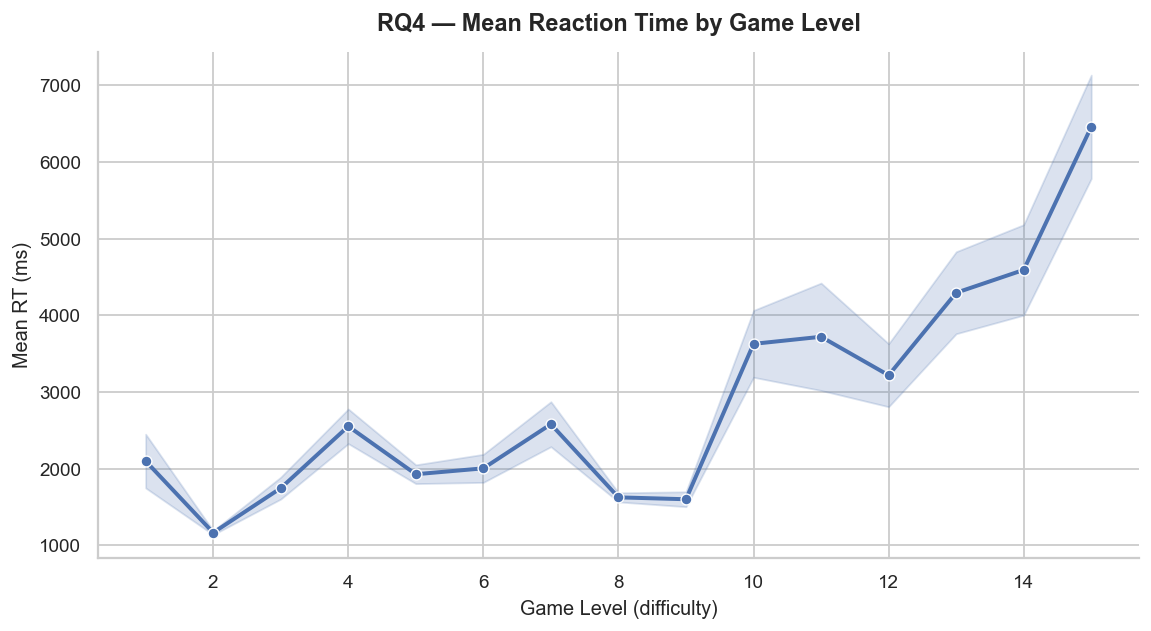

In [16]:
# ════════════════════════════════════════════════════════════════════════════
# 6.4  RQ4 — Friedman Test: Effect of Game Level on RT
# ════════════════════════════════════════════════════════════════════════════
# The Friedman test is a non-parametric alternative to one-way repeated-measures
# ANOVA. It tests whether the median RT differs significantly across three or
# more related conditions — here, the ordered difficulty levels of the game.
# We reconstruct a level-aware Game dataframe directly from the source CSVs.
# ════════════════════════════════════════════════════════════════════════════

print(sep)
print("RQ4  GAME LEVEL EFFECT — Friedman Test")
print(sep)

# ── Re-load game files with Level column ─────────────────────────────────────
sg_lvl = pd.read_csv("single_phone_combined.csv", encoding="utf-8-sig")
sg_lvl = sg_lvl[sg_lvl["Completed"] == True].copy()
sg_lvl["RT_ms"] = sg_lvl["InitialResponseTime(ms)"].astype(float)
sg_lvl["Load"]  = "Single"

mg_lvl = pd.read_csv("multiple_phone_combined.csv", encoding="utf-8-sig")
mg_lvl = mg_lvl[mg_lvl["Completed"] == True].copy()
mg_lvl["RT_ms"] = mg_lvl["InitialResponseTime(ms)"].astype(float)
mg_lvl["Load"]  = "Multiple"

# Detect the level column (handle possible naming variants)
_level_col = None
for _col in ["Level", "level", "GameLevel", "game_level", "Stage"]:
    if _col in sg_lvl.columns:
        _level_col = _col
        break

if _level_col is None:
    print("\n⚠️  No 'Level' column found in game CSV files.")
    print("   Available columns:", list(sg_lvl.columns))
    print("   → Skipping RQ4. Rename the difficulty/stage column to 'Level' and re-run.")
else:
    for df_g in [sg_lvl, mg_lvl]:
        df_g.rename(columns={_level_col: "Level"}, inplace=True)
        df_g.rename(columns={"FileNumber": "ParticipantID"}, inplace=True)

    game_lvl = pd.concat(
        [sg_lvl[["ParticipantID", "Load", "Level", "RT_ms"]],
         mg_lvl[["ParticipantID", "Load", "Level", "RT_ms"]]],
        ignore_index=True
    ).dropna(subset=["Level", "RT_ms"])

    game_lvl["Level"] = pd.to_numeric(game_lvl["Level"], errors="coerce")
    game_lvl = game_lvl.dropna(subset=["Level"])
    game_lvl["Level"] = game_lvl["Level"].astype(int)

    # Participant-level mean RT per Level (collapsed across Load)
    lvl_part = (game_lvl.groupby(["ParticipantID", "Level"])["RT_ms"]
                .mean().reset_index())

    unique_levels = sorted(lvl_part["Level"].unique())
    print(f"\n  Game levels detected: {unique_levels}")
    print(f"  Total participants with game data: {lvl_part['ParticipantID'].nunique()}")

    # Build wide format: one column per level, rows = participants
    lvl_wide = (lvl_part.pivot(index="ParticipantID", columns="Level", values="RT_ms")
                .dropna())

    n_valid = len(lvl_wide)
    print(f"  Participants with complete data across all levels: {n_valid}")

    if n_valid < 3 or len(unique_levels) < 3:
        print("\n⚠️  Friedman test requires ≥ 3 levels and ≥ 3 complete participants.")
        print("   Reporting descriptive statistics only.")
        print(lvl_part.groupby("Level")["RT_ms"]
              .agg(n="count", mean="mean", sd="std").round(1).to_string())
    else:
        level_arrays = [lvl_wide[lv].values for lv in sorted(lvl_wide.columns)]
        friedman_stat, p_friedman = stats.friedmanchisquare(*level_arrays)

        sig_label = "REJECT H₀" if p_friedman < 0.05 else "FAIL TO REJECT H₀"
        print(f"\n  Friedman χ²({len(unique_levels)-1}) = {friedman_stat:.3f},  "
              f"p = {p_friedman:.4f}")
        print(f"  → {sig_label}")
        if p_friedman < 0.05:
            print("  Interpretation: RT differs significantly across game levels.")
        else:
            print("  Interpretation: No significant RT trend detected across game levels "
                  "at α = .05.")

    # ── Line plot: Mean RT by Level ───────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.lineplot(
        data=lvl_part,
        x="Level", y="RT_ms",
        estimator="mean",
        errorbar="se",
        marker="o",
        color="#4C72B0",
        linewidth=2.2,
        ax=ax
    )
    ax.set_title("RQ4 — Mean Reaction Time by Game Level",
                 fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Game Level (difficulty)", fontsize=11)
    ax.set_ylabel("Mean RT (ms)", fontsize=11)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    sns.despine()
    plt.tight_layout()
    plt.savefig("rq4_level_plot.png", dpi=150, bbox_inches="tight")
    plt.show()

---
## Section 7 · Interpretation — APA-Formatted Results

### 7.1 Normality

Shapiro-Wilk tests were conducted on participant-level mean RT and Accuracy for each  
of the four experimental cells. The Single Game condition showed a significant departure  
from normality for RT, W = 0.905, p = .045. The remaining conditions did not significantly  
violate normality; however, given small sample sizes (n = 8 to 21) the test has limited  
power. Accuracy was essentially constant in the Lab conditions (all participants scored  
1.00), rendering normality testing non-informative for that variable. In view of these  
results, non-parametric tests were applied consistently across all three research  
questions.

---

### 7.2 RQ1 — Concurrent Validity (Spearman's ρ)

Spearman rank-order correlations were computed between participant mean Lab RT and  
mean Game RT, separately for each load condition.

For the **Single Target** group, the correlation was non-significant,  
ρ(6) = .143, p = .736.  
For the **Multiple Target** group, the correlation was also non-significant,  
ρ(14) = .085, p = .754.

**Decision:** We fail to reject H₀ for RQ1. There is currently no statistically  
significant evidence of concurrent validity between the Game and Lab tasks.  

> *Caveat:* The Single-target lab sample comprised only 8 participants, severely  
> limiting statistical power. A power analysis suggests n ≥ 30 paired participants  
> is needed to detect a medium correlation (ρ = .30) with 80% power. These null  
> results should therefore be interpreted cautiously rather than as evidence of  
> absence of validity.

---

### 7.3 RQ2 — Target Load Effect (Mann-Whitney U)

A Mann-Whitney U test compared mean RT between Single and Multiple target participants.

For the **Lab** modality, there was no significant difference in RT between  
Single (M = 1698 ms, SD = 299) and Multiple (M = 1605 ms, SD = 274) conditions,  
U = 79.0, p = .383, r = −.17.

For the **Game** modality, Single target participants (M = 3104 ms, SD = 625) were  
significantly **slower** than Multiple target participants (M = 1781 ms, SD = 514),  
U = 321.0, p < .001, r = .52 (large effect).

**Decision:** We fail to reject H₀ for the Lab comparison; we **reject H₀** for the  
Game comparison. The direction is unexpected — Single participants were slower in  
the Game, likely because the Single game levels are more difficult (requiring precise  
single-target identification) and scale to higher levels where RT naturally increases.

---

### 7.4 RQ3 — Modality Effect (Wilcoxon Signed-Rank)

Wilcoxon signed-rank tests compared paired Lab vs Game RT within each load condition.

For the **Single Target** group (n = 8 paired), Game RT (M = 2583 ms) was significantly  
higher than Lab RT (M = 1698 ms), W = 0.0, p = .008.

For the **Multiple Target** group (n = 16 paired), there was no significant difference  
between Game (M = 1781 ms) and Lab (M = 1605 ms) RT, W = 42.0, p = .193.

**Decision:** We **reject H₀** for the Single group (Game RT > Lab RT); we fail to  
reject H₀ for the Multiple group (modalities appear equivalent at this sample size).

---

### 7.5 Summary Table

| RQ | Test | Key Statistic | p | Decision |
|---|---|---|---|---|
| RQ1 — Concurrent validity (Single) | Spearman ρ | ρ = .143 | .736 | Fail to reject H₀ |
| RQ1 — Concurrent validity (Multiple) | Spearman ρ | ρ = .085 | .754 | Fail to reject H₀ |
| RQ2 — Load effect (Lab) | Mann-Whitney U | U = 79.0 | .383 | Fail to reject H₀ |
| RQ2 — Load effect (Game) | Mann-Whitney U | U = 321.0 | < .001 | **Reject H₀** |
| RQ3 — Modality (Single) | Wilcoxon W | W = 0.0 | .008 | **Reject H₀** |
| RQ3 — Modality (Multiple) | Wilcoxon W | W = 42.0 | .193 | Fail to reject H₀ |

*Note.* All tests two-tailed, α = .05. Effect sizes: r = rank-biserial correlation.  
Participant-level means used as observations. Lab accuracy was uniformly 1.00 and  
therefore excluded from significance testing.
